Shape of smoke volume['raw']: (125, 1250, 1250)


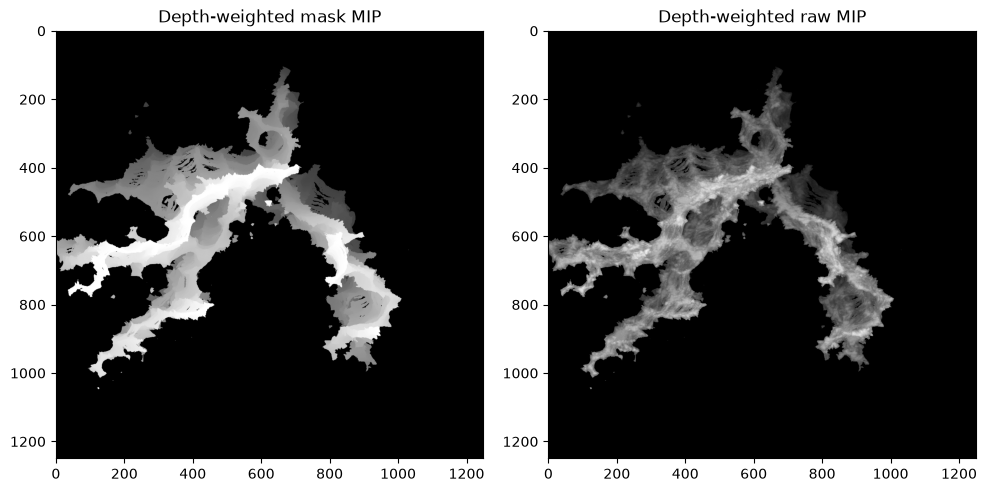

In [12]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import h5py as h5
vol = h5.File('../data/smoke_data/sample_A_20160501.hdf', 'r')
vol.keys()
images = vol['volumes']
segments = vol['annotations']

print('Shape of smoke volume[\'raw\']:', images['raw'].shape)
neuron_ids = np.array(images['labels']['neuron_ids'])  # copy, so this doesn't mutate images[...] in place
mask = neuron_ids == 20474        # compute the boolean mask once, before any mutation

ids, counts = np.unique(neuron_ids, return_counts=True)
most_frequent_label = ids[np.argmax(counts)]   # need the ids[...] lookup!
# list of all neuron_ids that are present in the volume, sorted by frequency
sorted_neuron_ids = ids[np.argsort(counts)[::-1]]
sorted_counts = counts[np.argsort(counts)[::-1]]
sorted_neuron_ids, sorted_counts  # top 10 neuron_ids and their counts

# Depth weights make near voxels brighter and far voxels darker along the camera sight.
# This is a simple depth cue on top of the MIP rather than a plain max projection.
depth_weights = np.linspace(1.0, 0.25, images['raw'].shape[0], dtype=np.float32)[:, None, None]
weighted_mask = mask.astype(np.float32) * depth_weights
weighted_raw = images['raw'].astype(np.float32) * weighted_mask

plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(np.max(weighted_mask, axis=0), cmap='gray', vmin=0, vmax=1)
plt.title('Depth-weighted mask MIP')
plt.subplot(1, 2, 2)
plt.imshow(np.max(weighted_raw, axis=0), cmap='gray')
plt.title('Depth-weighted raw MIP')
plt.tight_layout()

In [ ]:
# 3D Gaussian rasterization pipeline
#
# Goal:
# Convert a set of 3D Gaussians into a 2D image by projecting each Gaussian
# into screen space, estimating its coverage, and compositing the contributions
# in depth order so nearer splats can dominate farther ones.
#
# ------------------------------------------------------------
# 1) Gather inputs
# ------------------------------------------------------------
# - means: 3D Gaussian centers in world or local coordinates
# - log_scales: per-axis Gaussian size parameters
# - quats: Gaussian orientations
# - inten / color / opacity: per-Gaussian appearance values
# - camera: view matrix, projection matrix, image size, near/far planes

# code:
import torch


ckpt_dir = '../models_smoke/block_z000_y001_x006/best.pth'


def gather_inputs(ckpt_dir):
    loaded_ckpt = torch.load(ckpt_dir, map_location='cpu')
    means = loaded_ckpt['means']
    log_scales = loaded_ckpt['log_scales']
    quats = loaded_ckpt['quats']
    inten = loaded_ckpt['intensities']

    return means, log_scales, quats, inten

means, log_scales, quats, inten = gather_inputs(ckpt_dir)
# ------------------------------------------------------------
# 2) Transform Gaussians into camera space
# ------------------------------------------------------------
# - Convert world-space means into the camera coordinate frame. 
# Add official format math: 
# - Rotate Gaussian covariance/orientation into the same frame
# - Keep track of whether the camera looks down +z, -z, or another axis

# code:


# ------------------------------------------------------------
# 3) Project each Gaussian to the image plane
# ------------------------------------------------------------
# - Project the 3D mean to a 2D center (u, v)
# - Estimate depth w for sorting / attenuation
# - Derive the screen-space ellipse from the 3D covariance
# - Compute the inverse covariance used by the rasterizer

# code:


# ------------------------------------------------------------
# 4) Cull / clamp / stabilize the splats
# ------------------------------------------------------------
# - Reject Gaussians fully outside the view frustum
# - Clamp extreme scales to avoid exploding footprints
# - Stabilize tiny or near-singular covariances with eps values
# - Optionally drop very low-opacity Gaussians early

# code:


# ------------------------------------------------------------
# 5) Bin Gaussians into image tiles
# ------------------------------------------------------------
# - Divide the image into fixed-size tiles
# - Assign each Gaussian to the tiles its projected ellipse overlaps
# - Build tile lists so each thread block only processes local contributors
# - This reduces wasted work and improves memory locality

# code:


# ------------------------------------------------------------
# 6) Rasterize within each tile
# ------------------------------------------------------------
# - Iterate over the Gaussians assigned to the tile
# - Evaluate the Gaussian falloff at each covered pixel
# - Apply the opacity / intensity contribution
# - Keep the computation numerically stable with clamping / eps

# code:


# ------------------------------------------------------------
# 7) Depth-aware compositing
# ------------------------------------------------------------
# - Sort or approximate-sort splats by depth
# - Accumulate nearer contributions first
# - Attenuate farther splats so they appear darker / less dominant
# - Combine alpha, color, and optional depth cue terms

# code:


# ------------------------------------------------------------
# 8) Write the final image
# ------------------------------------------------------------
# - Normalize the accumulated output if needed
# - Apply tone mapping or grayscale conversion
# - Clamp to display range
# - Return or save the rendered image

# code:


/tmp/ipykernel_816954/1392383062.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_ckpt = torch.load(ckpt_dir, map_location='cpu')


In [5]:
# Lazy, overlap-based block cache — no upfront merge of all 27 blocks, and no
# stitched_volume either: the global (D,H,W) shape is pure block-size metadata
# (compute_global_shape), so nothing needs to load or stitch actual voxel data
# just to know the region's dimensions. Logic lives in
# scripts/render_scripts/sliding_window_camera.py; this cell just constructs
# the cache for our trained region's block layout (z=2 is ragged: 25 voxels
# deep, since smoke_data's z axis is 125 = 2x50 + 25).
import sys
sys.path.insert(0, '/root/project')
import torch
from scripts.render_scripts.sliding_window_camera import BlockGaussianCache, compute_global_shape

# base block indices (start of the 3x3x3 grid) — matches the actually-trained
# blocks in models_smoke/block_z0NN_y0NN_x0NN/, NOT (0,0,0)
base_z, base_y, base_x = 0, 1, 6
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

global_shape = compute_global_shape(
    grid_n=3, block_size=50,
    block_shape_fn=lambda dz, dy, dx: (25 if dz == 2 else 50, 50, 50),
)
print(f'Global shape (from block metadata, no data loaded): {global_shape}')

block_cache = BlockGaussianCache(
    blocks_dir='../models_smoke', base_zyx=(base_z, base_y, base_x), grid_n=3,
    global_shape=global_shape, block_size=50,
    block_shape_fn=lambda dz, dy, dx: (25 if dz == 2 else 50, 50, 50),
    device=device,
)
print('Cache ready — nothing loaded yet (loads lazily per window position).')

/venv/r3-ml/lib/python3.11/site-packages/torch/utils/cpp_extension.py:1964: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(


Global shape (from block metadata, no data loaded): (125, 150, 150)
Cache ready — nothing loaded yet (loads lazily per window position).


In [6]:
# render_sliding_block: puts the camera at the sliding window's centre and
# rotates 360 degrees looking outward, using only the Gaussians whose mean
# falls inside the window (pulled from block_cache). Logic lives in
# scripts/render_scripts/sliding_window_camera.py — this cell just imports it.
from scripts.render_scripts.sliding_window_camera import render_sliding_block

In [7]:
# Quick sanity check on one block directly (no stitching) — just to confirm
# the raw block data itself looks right before navigating with the Gaussians.
import h5py as h5_check
with h5_check.File('../data/smoke_data/blocks/block_z0_y1_x6.h5', 'r') as f:
    block_raw = f['raw'][:]
print('block_z0_y1_x6 raw shape:', block_raw.shape)
# plt.imshow(block_raw[0], cmap='gray')

block_z0_y1_x6 raw shape: (50, 50, 50)


In [8]:
%matplotlib inline
# Directly run the CUDA eval kernel inside the sliding cube, then compare it
# against the GT DVR/MIP render from the same cube. The splat result is a
# blob-like Gaussian projection; the GT view is what carries the volume detail.
import time
import importlib
import numpy as np
import torch
import matplotlib.pyplot as plt

import scripts.render_scripts.sliding_window_camera as swc
swc = importlib.reload(swc)
from scripts.render_scripts.render_camera import render_frame
from scripts._3dgs._3dgs import _load_eval_kernel

center_zyx = (62, 75, 75)
block_size = 32
img_size = 256
azimuth_deg = 0.0

# Reuse the existing block_cache (no separate cache, no stitched_volume needed).
windowed_gc = block_cache.get_gaussians_for_window(center_zyx, block_size)
local_gc, bounds = swc.filter_gaussians_in_block(windowed_gc, center_zyx, block_size, block_cache.global_shape)
means, log_s = swc.recenter_and_rescale(local_gc, bounds)

# Rotate the world by -azimuth so the fixed Z-projection matches the camera yaw.
theta = torch.tensor(-np.radians(azimuth_deg), device=means.device, dtype=means.dtype)
c, s = torch.cos(theta), torch.sin(theta)
R_y = torch.tensor([[c, 0.0, s], [0.0, 1.0, 0.0], [-s, 0.0, c]], device=means.device, dtype=means.dtype)
means_rot = means @ R_y.T
q_delta = torch.stack([
    torch.cos(theta / 2),
    torch.zeros((), device=means.device, dtype=means.dtype),
    torch.sin(theta / 2),
    torch.zeros((), device=means.device, dtype=means.dtype),
]).unsqueeze(0).expand(means.shape[0], 4)
quats_rot = swc.quat_multiply(q_delta, local_gc.quats)

kernel = _load_eval_kernel()
if torch.cuda.is_available():
    torch.cuda.synchronize()
t0 = time.perf_counter()
flat = kernel.splat_mip(
    means_rot.contiguous(),
    log_s.contiguous(),
    quats_rot.contiguous(),
    local_gc.inten.contiguous(),
    -1.0, 1.0, -1.0, 1.0, -1.0, 1.0,
    img_size, img_size, 32, 0,
    float(local_gc.scale_min), float(local_gc.mahal_clamp),
)
if torch.cuda.is_available():
    torch.cuda.synchronize()
splat_ms = (time.perf_counter() - t0) * 1000
splat_frame = flat.reshape(img_size, img_size).clamp(0, 1).cpu().numpy().astype(np.float32)

# Build the GT cube from the same sliding window, then render it with DVR/MIP.
gt_vol = swc.reconstruct_local_cube(local_gc, bounds, block_size, block_cache.device)
if torch.cuda.is_available():
    torch.cuda.synchronize()
t0 = time.perf_counter()
gt_frame = render_frame(gt_vol, azimuth_deg=0.0, elev_deg=0.0, fov_deg=90.0, img_h=img_size, img_w=img_size, n_steps=128)
if torch.cuda.is_available():
    torch.cuda.synchronize()
gt_ms = (time.perf_counter() - t0) * 1000

print(f'Direct CUDA eval kernel inside sliding cube: {splat_ms:.1f} ms for {img_size}x{img_size}')
print(f'GT DVR/MIP inside same cube: {gt_ms:.1f} ms for {img_size}x{img_size}')
print(f'Gaussians inside cube: {local_gc.means.shape[0]:,}')

fig, axs = plt.subplots(1, 3, figsize=(14, 4))
axs[0].imshow(gt_frame, cmap='gray', vmin=0, vmax=1)
axs[0].set_title('GT DVR/MIP')
axs[1].imshow(splat_frame, cmap='gray', vmin=0, vmax=1)
axs[1].set_title('direct splat_mip')
axs[2].imshow(np.abs(gt_frame - splat_frame), cmap='magma')
axs[2].set_title('abs diff')
plt.tight_layout()
plt.show()


/root/project/scripts/_3dgs/_3dgs.py:1008: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(str(path), map_location="cpu")


  window overlaps blocks [(0, 1, 1), (1, 1, 1)] (2 resident in cache)


/venv/r3-ml/lib/python3.11/site-packages/torch/utils/cpp_extension.py:1964: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(


Direct CUDA eval kernel inside sliding cube: 8.8 ms for 256x256
GT DVR/MIP inside same cube: 896.4 ms for 256x256
Gaussians inside cube: 13,876


/tmp/ipykernel_816954/4145367966.py:79: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [7]:
# load the pretrained model
ckpt = torch.load('../models_smoke/block_z001_y003_x008/best.pth', map_location='cuda')
# Normalize the quaternion
def normalize_quaternion(q):
    norm = torch.norm(q, dim=-1, keepdim=True)
    return q / norm
ckpt['quats'] = normalize_quaternion(ckpt['quats'])
#  Build the rotation matrix R
def rotation_matrix(q):
    # Convert quaternion to rotation matrix
    w, x, y, z = q[..., 0], q[..., 1], q[..., 2], q[..., 3]
    R = torch.stack([
        1 - 2 * (y**2 + z**2), 2 * (x * y - z * w), 2 * (x * z + y * w),
        2 * (x * y + z * w), 1 - 2 * (x**2 + z**2), 2 * (y * z - x * w),
        2 * (x * z - y * w), 2 * (y * z + x * w), 1 - 2 * (x**2 + y**2)
    ], dim=-1).reshape(q.shape[:-1] + (3, 3))
    return R
q = ckpt['quats']
R = rotation_matrix(q)
# Recover the scales.
print(ckpt.keys())
log_scales = ckpt['log_scales']
def recover_scales(scales_logs):
    scales = torch.exp(scales_logs)
    return scales
scales = recover_scales(log_scales)
# Clamp the scales
def clamp_scales(scales, scale_min=0.01, scale_max=1.0):
    return torch.clamp(scales, min=scale_min, max=scale_max)
scales = clamp_scales(scales)
# Build the covariance Σ
def build_covariance(scales, R):
    # Σ = R * diag(scales^2) * R^T
    diag_scales_squared = torch.diag_embed(scales**2)
    covariance = R @ diag_scales_squared @ R.transpose(-1, -2)
    return covariance
covariance = build_covariance(scales, R)
# Build the inverse covariance Σ⁻¹
def build_inverse_covariance(covariance):
    return torch.linalg.inv(covariance)
inverse_covariance = build_inverse_covariance(covariance)

dict_keys(['means', 'log_scales', 'quats', 'intensities', 'inten_param'])


/tmp/ipykernel_680983/1806469414.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load('../models_smoke/block_z001_y003_x008/best.pth', map_location='cuda')


In [8]:
%matplotlib inline
import time
import importlib
import numpy as np
import matplotlib.pyplot as plt
import torch

import scripts.render_scripts.py_tiled_mip as py_tiled_mip
py_tiled_mip = importlib.reload(py_tiled_mip)
from scripts.render_scripts.py_tiled_mip import render_checkpoint, render_tiled_mip

ckpt_path = '../models_smoke/block_z001_y003_x008/best.pth'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if torch.cuda.is_available():
    torch.cuda.synchronize()
t0 = time.perf_counter()
image, prepared = render_checkpoint(
    ckpt_path,
    out_h=256,
    out_w=256,
    tile_size=16,
    depth_samples=16,
    max_gauss_per_tile=512,
    density_scale=1.0,
    device=device,
 )
if torch.cuda.is_available():
    torch.cuda.synchronize()
full_elapsed_ms = (time.perf_counter() - t0) * 1000
full_fps = 1000.0 / full_elapsed_ms if full_elapsed_ms > 0 else float('inf')

# Render-only timing: reuse the cached prepared scene and skip checkpoint loading / binning.
if torch.cuda.is_available():
    torch.cuda.synchronize()
t0 = time.perf_counter()
repeat_count = 3
for _ in range(repeat_count):
    render_tiled_mip(prepared, depth_samples=16, coarse_to_fine=True)
if torch.cuda.is_available():
    torch.cuda.synchronize()
render_only_elapsed_ms = (time.perf_counter() - t0) * 1000 / repeat_count
render_only_fps = 1000.0 / render_only_elapsed_ms if render_only_elapsed_ms > 0 else float('inf')

print(f'Full pipeline render: {full_elapsed_ms:.1f} ms')
print(f'Full pipeline FPS: {full_fps:.3f}')
print(f'Render-only cached scene: {render_only_elapsed_ms:.1f} ms')
print(f'Render-only FPS: {render_only_fps:.3f}')
print(f'Tile avg occupancy: {prepared.avg_tile_occupancy:.1f}')
print(f'Tile max occupancy: {prepared.max_tile_occupancy}')
print(f'Capped tiles: {prepared.capped_tiles}')

plt.figure(figsize=(5, 5))
plt.imshow(image.detach().cpu().numpy(), cmap='gray', vmin=0, vmax=1)
plt.axis('off')
plt.title('Python tiled MIP')
plt.savefig('python_tiled_mip.png', dpi=300, bbox_inches='tight')
plt.show()

/root/project/scripts/_3dgs/_3dgs.py:1008: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(str(path), map_location="cpu")


  splat_mip tiles: 256 tiles, avg occupancy 512.0, max occupancy 2759, capped 256 tiles, pruned 426279 gaussians
Full pipeline render: 8226.4 ms
Full pipeline FPS: 0.122
Render-only cached scene: 1067.1 ms
Render-only FPS: 0.937
Tile avg occupancy: 512.0
Tile max occupancy: 2759
Capped tiles: 256


/tmp/ipykernel_680983/320763111.py:58: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


  splat_mip tiles: 16 tiles, avg occupancy 512.0, max occupancy 9399, capped 16 tiles, pruned 105621 gaussians
Preview render-only (64x64, depth_samples=16): 51.5 ms
Preview FPS: 19.407
Tile avg occupancy: 512.0
Tile max occupancy: 9399
Capped tiles: 16


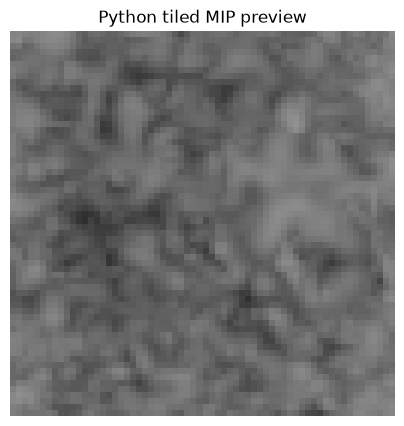

In [11]:
%matplotlib inline
import time
import numpy as np
import matplotlib.pyplot as plt
import torch

from scripts.render_scripts.py_tiled_mip import render_checkpoint, render_tiled_mip

preview_out = 64
preview_depth_samples = 16
preview_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

preview_image, preview_prepared = render_checkpoint(
    ckpt_path,
    out_h=preview_out,
    out_w=preview_out,
    tile_size=16,
    depth_samples=preview_depth_samples,
    max_gauss_per_tile=512,
    density_scale=1.0,
    device=preview_device,
 )

if torch.cuda.is_available():
    torch.cuda.synchronize()
t0 = time.perf_counter()
repeat_count = 5
for _ in range(repeat_count):
    render_tiled_mip(preview_prepared, depth_samples=preview_depth_samples, coarse_to_fine=True)
if torch.cuda.is_available():
    torch.cuda.synchronize()
preview_elapsed_ms = (time.perf_counter() - t0) * 1000 / repeat_count
preview_fps = 1000.0 / preview_elapsed_ms if preview_elapsed_ms > 0 else float('inf')

print(f'Preview render-only ({preview_out}x{preview_out}, depth_samples={preview_depth_samples}): {preview_elapsed_ms:.1f} ms')
print(f'Preview FPS: {preview_fps:.3f}')
print(f'Tile avg occupancy: {preview_prepared.avg_tile_occupancy:.1f}')
print(f'Tile max occupancy: {preview_prepared.max_tile_occupancy}')
print(f'Capped tiles: {preview_prepared.capped_tiles}')

plt.figure(figsize=(5, 5))
plt.imshow(preview_image.detach().cpu().numpy(), cmap='gray', vmin=0, vmax=1, interpolation='nearest')
plt.axis('off')
plt.title('Python tiled MIP preview')
plt.show()

In [ ]:
from scripts.render_scripts.py_tiled_mip import render_tiled_mip
for out_size, depth_samples in [(256, 16), (128, 8), (128, 4), (64, 4), (64, 2)]:
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    repeat_count = 3
    for _ in range(repeat_count):
        render_tiled_mip(
            prepared,
            depth_samples=depth_samples,
            coarse_to_fine=True,
        )
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed_ms = (time.perf_counter() - t0) * 1000 / repeat_count
    fps = 1000.0 / elapsed_ms if elapsed_ms > 0 else float('inf')
    print(f'cached render preview depth_samples={depth_samples}: {elapsed_ms:.1f} ms, FPS={fps:.3f}')

cached render preview depth_samples=16: 982.6 ms, FPS=1.018
cached render preview depth_samples=8: 499.7 ms, FPS=2.001
cached render preview depth_samples=4: 339.5 ms, FPS=2.946
cached render preview depth_samples=4: 305.9 ms, FPS=3.269
cached render preview depth_samples=2: 184.6 ms, FPS=5.418


In [ ]:
from scripts.render_scripts.py_tiled_mip import render_checkpoint, render_tiled_mip
preview_sizes = [(128, 4), (64, 4), (64, 2)]
for out_size, depth_samples in preview_sizes:
    preview_image, preview_prepared = render_checkpoint(
        ckpt_path,
        out_h=out_size,
        out_w=out_size,
        tile_size=16,
        depth_samples=depth_samples,
        max_gauss_per_tile=512,
        density_scale=1.0,
        device=device,
    )
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    repeat_count = 3
    for _ in range(repeat_count):
        render_tiled_mip(preview_prepared, depth_samples=depth_samples, coarse_to_fine=True)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed_ms = (time.perf_counter() - t0) * 1000 / repeat_count
    fps = 1000.0 / elapsed_ms if elapsed_ms > 0 else float('inf')
    print(f'preview {out_size}x{out_size}, depth_samples={depth_samples}: {elapsed_ms:.1f} ms, FPS={fps:.3f}')

  splat_mip tiles: 64 tiles, avg occupancy 512.0, max occupancy 4454, capped 64 tiles, pruned 193456 gaussians
preview 128x128, depth_samples=4: 71.0 ms, FPS=14.089
  splat_mip tiles: 16 tiles, avg occupancy 512.0, max occupancy 9399, capped 16 tiles, pruned 105621 gaussians
preview 64x64, depth_samples=4: 18.5 ms, FPS=54.043
  splat_mip tiles: 16 tiles, avg occupancy 512.0, max occupancy 9399, capped 16 tiles, pruned 105621 gaussians
preview 64x64, depth_samples=2: 11.2 ms, FPS=89.342


  window overlaps blocks [(0, 1, 1), (1, 1, 1)] (2 resident in cache)


128x128, request d=128: CUDA pred 2.9 ms, FPS=346.774; gt 196.4 ms; density_scale=0.1; pred peak=6.942e-01
  gt p1/p99.5=5.941e-01/8.767e-01 | pred p1/p99.5=3.085e-01/6.829e-01
  window overlaps blocks [(0, 1, 1), (1, 1, 1)] (2 resident in cache)
64x64, request d=32: CUDA pred 2.1 ms, FPS=467.847; gt 45.9 ms; density_scale=0.1; pred peak=6.923e-01
  gt p1/p99.5=5.879e-01/8.773e-01 | pred p1/p99.5=2.900e-01/6.831e-01
  window overlaps blocks [(0, 1, 1), (1, 1, 1)] (2 resident in cache)
64x64, request d=16: CUDA pred 2.1 ms, FPS=475.208; gt 44.7 ms; density_scale=0.1; pred peak=6.923e-01
  gt p1/p99.5=5.879e-01/8.773e-01 | pred p1/p99.5=2.900e-01/6.831e-01


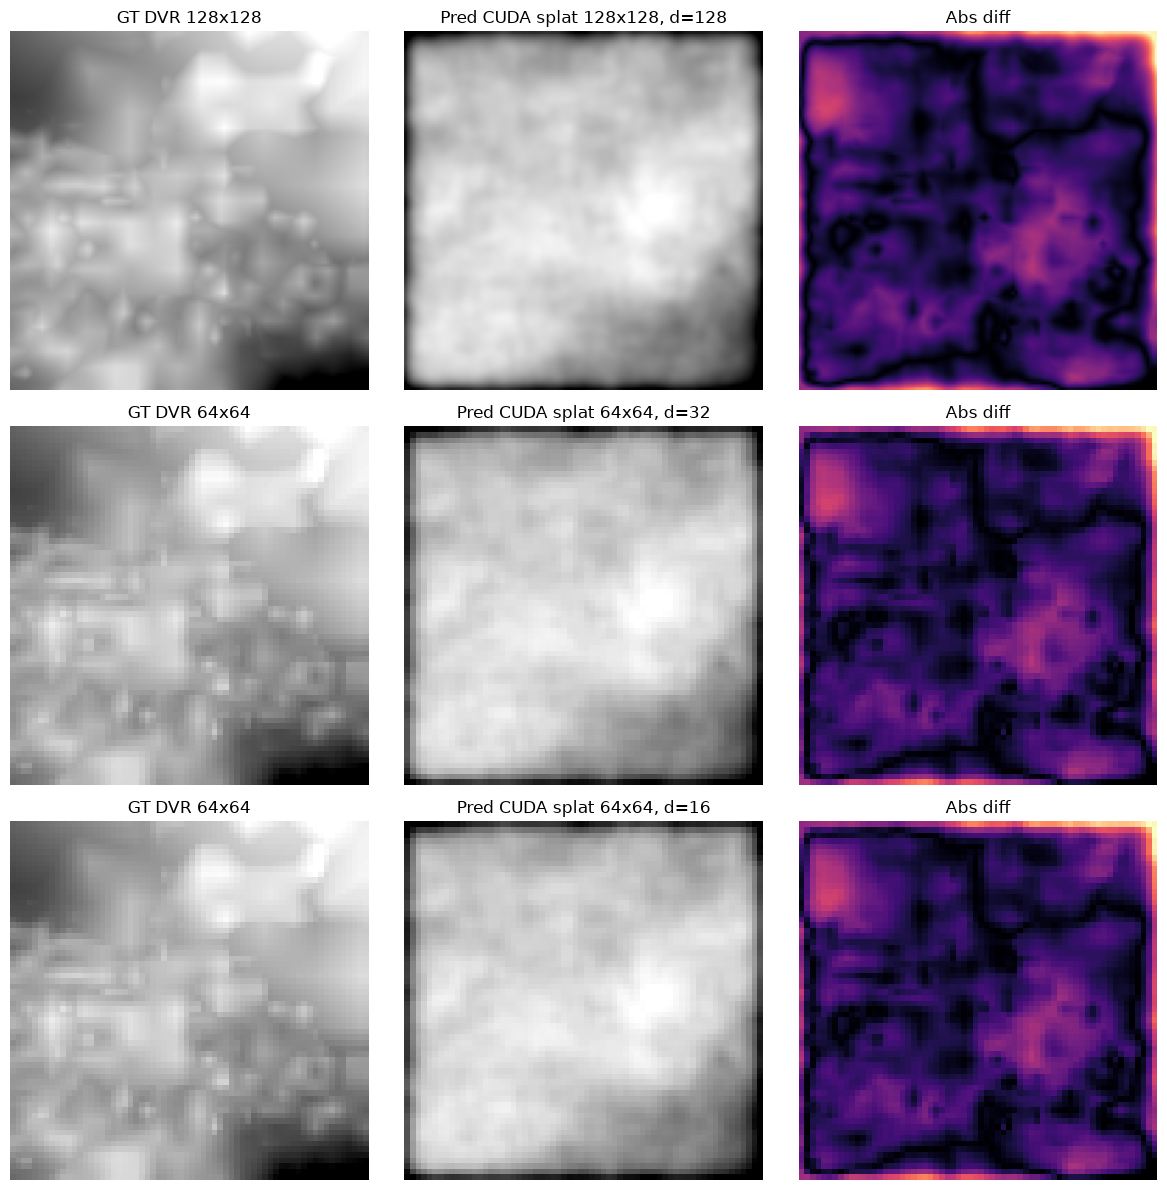

In [15]:
%matplotlib inline
import time
import importlib
import numpy as np
import matplotlib.pyplot as plt
import torch

import scripts.render_scripts.sliding_window_camera as swc
swc = importlib.reload(swc)
from scripts.render_scripts.render_camera import render_frame

center_zyx = (62, 75, 75)
block_size = 32
compare_specs = [
    (128, 128),
    (64, 32),
    (64, 16),
]
density_scale = 0.1

fig, axes = plt.subplots(len(compare_specs), 3, figsize=(12, 4 * len(compare_specs)))
if len(compare_specs) == 1:
    axes = np.array([axes])

for row, (out_size, depth_samples) in enumerate(compare_specs):
    windowed_gc = block_cache.get_gaussians_for_window(center_zyx, block_size)
    local_gc, bounds = swc.filter_gaussians_in_block(windowed_gc, center_zyx, block_size, block_cache.global_shape)
    means, log_s = swc.recenter_and_rescale(local_gc, bounds)

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    pred_frame = swc.render_frame_cuda_splat(
        means,
        log_s,
        local_gc.quats,
        local_gc.inten,
        azimuth_deg=0.0,
        scale_min=float(local_gc.scale_min),
        mahal_clamp=float(local_gc.mahal_clamp),
        img_size=out_size,
        depth_samples=depth_samples,
        density_scale=density_scale,
    )
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    pred_ms = (time.perf_counter() - t0) * 1000
    pred_fps = 1000.0 / pred_ms if pred_ms > 0 else float('inf')
    pred_peak = float(np.max(pred_frame))
    pred_lo = float(np.percentile(pred_frame, 1.0))
    pred_hi = float(np.percentile(pred_frame, 99.5))
    pred_vis = np.clip((pred_frame - pred_lo) / max(pred_hi - pred_lo, 1e-8), 0.0, 1.0)

    gt_vol = swc.reconstruct_local_cube(local_gc, bounds, block_size, block_cache.device)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    gt_frame = render_frame(gt_vol, azimuth_deg=0.0, elev_deg=0.0, fov_deg=90.0, img_h=out_size, img_w=out_size, n_steps=128)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    gt_ms = (time.perf_counter() - t0) * 1000
    gt_lo = float(np.percentile(gt_frame, 1.0))
    gt_hi = float(np.percentile(gt_frame, 99.5))
    gt_vis = np.clip((gt_frame - gt_lo) / max(gt_hi - gt_lo, 1e-8), 0.0, 1.0)

    diff = np.abs(gt_vis - pred_vis)

    print(f'{out_size}x{out_size}, request d={depth_samples}: CUDA pred {pred_ms:.1f} ms, FPS={pred_fps:.3f}; gt {gt_ms:.1f} ms; density_scale={density_scale}; pred peak={pred_peak:.3e}')
    print(f'  gt p1/p99.5={gt_lo:.3e}/{gt_hi:.3e} | pred p1/p99.5={pred_lo:.3e}/{pred_hi:.3e}')

    axes[row, 0].imshow(gt_vis, cmap='gray', vmin=0, vmax=1)
    axes[row, 0].set_title(f'GT DVR {out_size}x{out_size}')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(pred_vis, cmap='gray', vmin=0, vmax=1)
    axes[row, 1].set_title(f'Pred CUDA splat {out_size}x{out_size}, d={depth_samples}')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(diff, cmap='magma')
    axes[row, 2].set_title('Abs diff')
    axes[row, 2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
print('prepared inten stats:', float(prepared.inten.min()), float(prepared.inten.max()), float(prepared.inten.mean()))
print('prepared mean ranges:', float(prepared.proj_u.min()), float(prepared.proj_u.max()), float(prepared.proj_v.min()), float(prepared.proj_v.max()), float(prepared.proj_w.min()), float(prepared.proj_w.max()))
print('prepared sigma_inv uu/vv/ww:', float(prepared.sigma_inv_uu.min()), float(prepared.sigma_inv_uu.max()), float(prepared.sigma_inv_vv.min()), float(prepared.sigma_inv_vv.max()), float(prepared.sigma_inv_ww.min()), float(prepared.sigma_inv_ww.max()))

prepared inten stats: 0.005001704674214125 0.7206605672836304 0.13817952573299408
prepared mean ranges: -1.0 1.0 -1.0 0.9999890327453613 -0.9999987483024597 1.0
prepared sigma_inv uu/vv/ww: 45.621925354003906 296938.5625 50.73371505737305 235919.890625 49.24275588989258 782902.75


In [ ]:
from dataclasses import replace
from scripts.render_scripts.py_tiled_mip import _render_tile
for scale in [1.0, 1e2, 1e4, 1e6]:
    probe = replace(prepared, density_scale=scale)
    tile_img = _render_tile(probe, 0, depth_samples=16, coarse_to_fine=True)
    print('scale', scale, 'tile0 stats', float(tile_img.min()), float(tile_img.max()), float(tile_img.mean()))

scale 1.0 tile0 stats 0.527813196182251 0.5926218032836914 0.5557142496109009
scale 100.0 tile0 stats 1.0 1.0 1.0
scale 10000.0 tile0 stats 1.0 1.0 1.0
scale 1000000.0 tile0 stats 1.0 1.0 1.0


In [ ]:
tile_counts = (prepared.tile_offsets[1:] - prepared.tile_offsets[:-1]).cpu().numpy()
best_tile = int(tile_counts.argmax())
print('best tile id:', best_tile, 'count:', int(tile_counts.max()))
probe = replace(prepared, density_scale=1e6)
tile_img = _render_tile(probe, best_tile, depth_samples=16, coarse_to_fine=True)
print('best tile stats', float(tile_img.min()), float(tile_img.max()), float(tile_img.mean()))

best tile id: 0 count: 512
best tile stats 1.0 1.0 1.0


In [ ]:
g = 0
u = prepared.proj_u[g]
v = prepared.proj_v[g]
w = prepared.proj_w[g]
a = prepared.sigma_inv_uu[g]
b = prepared.sigma_inv_uv[g]
c = prepared.sigma_inv_uw[g]
d = prepared.sigma_inv_vv[g]
e = prepared.sigma_inv_vw[g]
f = prepared.sigma_inv_ww[g]
du = u - u
dv = v - v
dw = w - w
mah_self = du * (a * du + b * dv + c * dw) + dv * (b * du + d * dv + e * dw) + dw * (c * du + e * dv + f * dw)
print('self mahal:', float(mah_self))
print('self intensity:', float(prepared.inten[g]))
print('exp contribution at self:', float(prepared.inten[g] * torch.exp(-0.5 * mah_self)))

self mahal: 0.0
self intensity: 0.10065347701311111
exp contribution at self: 0.10065347701311111


In [ ]:
for depth_samples in [16, 64, 256, 1024]:
    tile_img = _render_tile(prepared, best_tile, depth_samples=depth_samples, coarse_to_fine=False)
    print('depth_samples', depth_samples, 'tile stats', float(tile_img.min()), float(tile_img.max()), float(tile_img.mean()))

depth_samples 16 tile stats 0.527813196182251 0.5926218032836914 0.5557142496109009
depth_samples 64 tile stats 0.527813196182251 0.5926218032836914 0.5557142496109009
depth_samples 256 tile stats 0.527813196182251 0.5926218032836914 0.5557142496109009
depth_samples 1024 tile stats 0.527813196182251 0.5926218032836914 0.5557142496109009


In [ ]:
print('image stats:', float(image.min()), float(image.max()), float(image.mean()))
print('prepared density_scale:', prepared.density_scale)
print('prepared avg occupancy:', prepared.avg_tile_occupancy)
print('prepared max occupancy:', prepared.max_tile_occupancy)

image stats: 0.29223281145095825 0.6065856218338013 0.4724264144897461
prepared density_scale: 1.0
prepared avg occupancy: 512.0
prepared max occupancy: 2759


In [ ]:
import importlib
import scripts.render_scripts.py_tiled_mip as ptm
ptm = importlib.reload(ptm)
from scripts.render_scripts.py_tiled_mip import _render_tile, PreparedTileMip
tile_counts = (prepared.tile_offsets[1:] - prepared.tile_offsets[:-1]).cpu().numpy()
best_tile = int(tile_counts.argmax())
for scale in [1e5, 1e6, 1e7, 1e8]:
    probe = PreparedTileMip(**{**prepared.__dict__, 'density_scale': float(scale)})
    tile_img = _render_tile(probe, best_tile, depth_samples=16, coarse_to_fine=True)
    print('scale', scale, 'tile stats', float(tile_img.min()), float(tile_img.max()), float(tile_img.mean()))

scale 100000.0 tile stats 1.0 1.0 1.0
scale 1000000.0 tile stats 1.0 1.0 1.0
scale 10000000.0 tile stats 1.0 1.0 1.0
scale 100000000.0 tile stats 1.0 1.0 1.0


In [ ]:
for scale in [1e-6, 1e-4, 1e-2, 1.0, 10.0, 100.0, 1000.0]:
    probe = PreparedTileMip(**{**prepared.__dict__, 'density_scale': float(scale)})
    tile_img = _render_tile(probe, best_tile, depth_samples=16, coarse_to_fine=True)
    print('scale', scale, 'tile stats', float(tile_img.min()), float(tile_img.max()), float(tile_img.mean()))

scale 1e-06 tile stats 7.748603820800781e-07 8.940696716308594e-07 8.055940270423889e-07
scale 0.0001 tile stats 7.49826431274414e-05 8.976459503173828e-05 8.115102536976337e-05
scale 0.01 tile stats 0.007475733757019043 0.008939981460571289 0.008084318600594997
scale 1.0 tile stats 0.527813196182251 0.5926218032836914 0.5557142496109009
scale 10.0 tile stats 0.9994490146636963 0.9998741149902344 0.9996895790100098
scale 100.0 tile stats 1.0 1.0 1.0
scale 1000.0 tile stats 1.0 1.0 1.0


In [ ]:
import h5py as h5
vol = h5.File('../data/smoke_data/sample_A_20160501.hdf', 'r')
vol.keys()
images = vol['volumes']
segments = vol['annotations']
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
print('Shape of smoke volume[\'raw\']:', images['raw'].shape)
neuron_ids = np.array(images['labels']['neuron_ids'])  # copy, so this doesn't mutate images[...] in place
mask = neuron_ids == 20474        # compute the boolean mask once, before any mutation


ids, counts = np.unique(neuron_ids, return_counts=True)
most_frequent_label = ids[np.argmax(counts)]   # need the ids[...] lookup!
# list of all neuron_ids that are present in the volume, sorted by frequency
sorted_neuron_ids = ids[np.argsort(counts)[::-1]]
sorted_counts = counts[np.argsort(counts)[::-1]]
sorted_neuron_ids, sorted_counts  # top 10 neuron_ids and their counts
plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(np.max(mask, axis=0))  # MIP of the mask itself (keeps the 3D shape, no fancy-indexing collapse)
plt.title(f'MIP of the mask for neuron_id {most_frequent_label}')
plt.subplot(1, 2, 2)
plt.imshow(np.max(images['raw']*mask, axis=0), cmap='gray')  # MIP of the masked raw data (keeps the 3D shape, no fancy-indexing collapse)
plt.title(f'MIP of the masked raw data for neuron_id {most_frequent_label}')

In [ ]:
# Lazy, overlap-based block cache — no upfront merge of all 27 blocks, and no
# stitched_volume either: the global (D,H,W) shape is pure block-size metadata
# (compute_global_shape), so nothing needs to load or stitch actual voxel data
# just to know the region's dimensions. Logic lives in
# scripts/render_scripts/sliding_window_camera.py; this cell just constructs
# the cache for our trained region's block layout (z=2 is ragged: 25 voxels
# deep, since smoke_data's z axis is 125 = 2x50 + 25).
import sys
sys.path.insert(0, '/root/project')
import torch
from scripts.render_scripts.sliding_window_camera import BlockGaussianCache, compute_global_shape

# base block indices (start of the 3x3x3 grid) — matches the actually-trained
# blocks in models_smoke/block_z0NN_y0NN_x0NN/, NOT (0,0,0)
base_z, base_y, base_x = 0, 1, 6
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

global_shape = compute_global_shape(
    grid_n=3, block_size=50,
    block_shape_fn=lambda dz, dy, dx: (25 if dz == 2 else 50, 50, 50),
)
print(f'Global shape (from block metadata, no data loaded): {global_shape}')

block_cache = BlockGaussianCache(
    blocks_dir='../models_smoke', base_zyx=(base_z, base_y, base_x), grid_n=3,
    global_shape=global_shape, block_size=50,
    block_shape_fn=lambda dz, dy, dx: (25 if dz == 2 else 50, 50, 50),
    device=device,
)
print('Cache ready — nothing loaded yet (loads lazily per window position).')

In [ ]:
# render_sliding_block: puts the camera at the sliding window's centre and
# rotates 360 degrees looking outward, using only the Gaussians whose mean
# falls inside the window (pulled from block_cache). Logic lives in
# scripts/render_scripts/sliding_window_camera.py — this cell just imports it.
from scripts.render_scripts.sliding_window_camera import render_sliding_block

In [ ]:
# Quick sanity check on one block directly (no stitching) — just to confirm
# the raw block data itself looks right before navigating with the Gaussians.
import h5py as h5_check
with h5_check.File('../data/smoke_data/blocks/block_z0_y1_x6.h5', 'r') as f:
    block_raw = f['raw'][:]
print('block_z0_y1_x6 raw shape:', block_raw.shape)
# plt.imshow(block_raw[0], cmap='gray')

In [ ]:
%matplotlib inline
# Directly run the CUDA eval kernel inside the sliding cube, then compare it
# against the GT DVR/MIP render from the same cube. The splat result is a
# blob-like Gaussian projection; the GT view is what carries the volume detail.
import time
import importlib
import numpy as np
import torch
import matplotlib.pyplot as plt

import scripts.render_scripts.sliding_window_camera as swc
swc = importlib.reload(swc)
from scripts.render_scripts.render_camera import render_frame
from scripts._3dgs._3dgs import _load_eval_kernel

center_zyx = (62, 75, 75)
block_size = 32
img_size = 256
azimuth_deg = 0.0

# Reuse the existing block_cache (no separate cache, no stitched_volume needed).
windowed_gc = block_cache.get_gaussians_for_window(center_zyx, block_size)
local_gc, bounds = swc.filter_gaussians_in_block(windowed_gc, center_zyx, block_size, block_cache.global_shape)
means, log_s = swc.recenter_and_rescale(local_gc, bounds)

# Rotate the world by -azimuth so the fixed Z-projection matches the camera yaw.
theta = torch.tensor(-np.radians(azimuth_deg), device=means.device, dtype=means.dtype)
c, s = torch.cos(theta), torch.sin(theta)
R_y = torch.tensor([[c, 0.0, s], [0.0, 1.0, 0.0], [-s, 0.0, c]], device=means.device, dtype=means.dtype)
means_rot = means @ R_y.T
q_delta = torch.stack([
    torch.cos(theta / 2),
    torch.zeros((), device=means.device, dtype=means.dtype),
    torch.sin(theta / 2),
    torch.zeros((), device=means.device, dtype=means.dtype),
]).unsqueeze(0).expand(means.shape[0], 4)
quats_rot = swc.quat_multiply(q_delta, local_gc.quats)

kernel = _load_eval_kernel()
if torch.cuda.is_available():
    torch.cuda.synchronize()
t0 = time.perf_counter()
flat = kernel.splat_mip(
    means_rot.contiguous(),
    log_s.contiguous(),
    quats_rot.contiguous(),
    local_gc.inten.contiguous(),
    -1.0, 1.0, -1.0, 1.0, -1.0, 1.0,
    img_size, img_size, 32, 0,
    float(local_gc.scale_min), float(local_gc.mahal_clamp),
)
if torch.cuda.is_available():
    torch.cuda.synchronize()
splat_ms = (time.perf_counter() - t0) * 1000
splat_frame = flat.reshape(img_size, img_size).clamp(0, 1).cpu().numpy().astype(np.float32)

# Build the GT cube from the same sliding window, then render it with DVR/MIP.
gt_vol = swc.reconstruct_local_cube(local_gc, bounds, block_size, block_cache.device)
if torch.cuda.is_available():
    torch.cuda.synchronize()
t0 = time.perf_counter()
gt_frame = render_frame(gt_vol, azimuth_deg=0.0, elev_deg=0.0, fov_deg=90.0, img_h=img_size, img_w=img_size, n_steps=128)
if torch.cuda.is_available():
    torch.cuda.synchronize()
gt_ms = (time.perf_counter() - t0) * 1000

print(f'Direct CUDA eval kernel inside sliding cube: {splat_ms:.1f} ms for {img_size}x{img_size}')
print(f'GT DVR/MIP inside same cube: {gt_ms:.1f} ms for {img_size}x{img_size}')
print(f'Gaussians inside cube: {local_gc.means.shape[0]:,}')

fig, axs = plt.subplots(1, 3, figsize=(14, 4))
axs[0].imshow(gt_frame, cmap='gray', vmin=0, vmax=1)
axs[0].set_title('GT DVR/MIP')
axs[1].imshow(splat_frame, cmap='gray', vmin=0, vmax=1)
axs[1].set_title('direct splat_mip')
axs[2].imshow(np.abs(gt_frame - splat_frame), cmap='magma')
axs[2].set_title('abs diff')
plt.tight_layout()
plt.show()


In [ ]:
# load the pretrained model
ckpt = torch.load('../models_smoke/block_z001_y003_x008/best.pth', map_location='cuda')
# Normalize the quaternion
def normalize_quaternion(q):
    norm = torch.norm(q, dim=-1, keepdim=True)
    return q / norm
ckpt['quats'] = normalize_quaternion(ckpt['quats'])
#  Build the rotation matrix R
def rotation_matrix(q):
    # Convert quaternion to rotation matrix
    w, x, y, z = q[..., 0], q[..., 1], q[..., 2], q[..., 3]
    R = torch.stack([
        1 - 2 * (y**2 + z**2), 2 * (x * y - z * w), 2 * (x * z + y * w),
        2 * (x * y + z * w), 1 - 2 * (x**2 + z**2), 2 * (y * z - x * w),
        2 * (x * z - y * w), 2 * (y * z + x * w), 1 - 2 * (x**2 + y**2)
    ], dim=-1).reshape(q.shape[:-1] + (3, 3))
    return R
q = ckpt['quats']
R = rotation_matrix(q)
# Recover the scales.
print(ckpt.keys())
log_scales = ckpt['log_scales']
def recover_scales(scales_logs):
    scales = torch.exp(scales_logs)
    return scales
scales = recover_scales(log_scales)
# Clamp the scales
def clamp_scales(scales, scale_min=0.01, scale_max=1.0):
    return torch.clamp(scales, min=scale_min, max=scale_max)
scales = clamp_scales(scales)
# Build the covariance Σ
def build_covariance(scales, R):
    # Σ = R * diag(scales^2) * R^T
    diag_scales_squared = torch.diag_embed(scales**2)
    covariance = R @ diag_scales_squared @ R.transpose(-1, -2)
    return covariance
covariance = build_covariance(scales, R)
# Build the inverse covariance Σ⁻¹
def build_inverse_covariance(covariance):
    return torch.linalg.inv(covariance)
inverse_covariance = build_inverse_covariance(covariance)

In [ ]:
%matplotlib inline
import time
import importlib
import numpy as np
import matplotlib.pyplot as plt
import torch

import scripts.render_scripts.py_tiled_mip as py_tiled_mip
py_tiled_mip = importlib.reload(py_tiled_mip)
from scripts.render_scripts.py_tiled_mip import render_checkpoint, render_tiled_mip

ckpt_path = '../models_smoke/block_z001_y003_x008/best.pth'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if torch.cuda.is_available():
    torch.cuda.synchronize()
t0 = time.perf_counter()
image, prepared = render_checkpoint(
    ckpt_path,
    out_h=256,
    out_w=256,
    tile_size=16,
    depth_samples=16,
    max_gauss_per_tile=512,
    density_scale=1.0,
    device=device,
 )
if torch.cuda.is_available():
    torch.cuda.synchronize()
full_elapsed_ms = (time.perf_counter() - t0) * 1000
full_fps = 1000.0 / full_elapsed_ms if full_elapsed_ms > 0 else float('inf')

# Render-only timing: reuse the cached prepared scene and skip checkpoint loading / binning.
if torch.cuda.is_available():
    torch.cuda.synchronize()
t0 = time.perf_counter()
repeat_count = 3
for _ in range(repeat_count):
    render_tiled_mip(prepared, depth_samples=16, coarse_to_fine=True)
if torch.cuda.is_available():
    torch.cuda.synchronize()
render_only_elapsed_ms = (time.perf_counter() - t0) * 1000 / repeat_count
render_only_fps = 1000.0 / render_only_elapsed_ms if render_only_elapsed_ms > 0 else float('inf')

print(f'Full pipeline render: {full_elapsed_ms:.1f} ms')
print(f'Full pipeline FPS: {full_fps:.3f}')
print(f'Render-only cached scene: {render_only_elapsed_ms:.1f} ms')
print(f'Render-only FPS: {render_only_fps:.3f}')
print(f'Tile avg occupancy: {prepared.avg_tile_occupancy:.1f}')
print(f'Tile max occupancy: {prepared.max_tile_occupancy}')
print(f'Capped tiles: {prepared.capped_tiles}')

plt.figure(figsize=(5, 5))
plt.imshow(image.detach().cpu().numpy(), cmap='gray', vmin=0, vmax=1)
plt.axis('off')
plt.title('Python tiled MIP')
plt.savefig('python_tiled_mip.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
%matplotlib inline
import time
import numpy as np
import matplotlib.pyplot as plt
import torch

from scripts.render_scripts.py_tiled_mip import render_checkpoint, render_tiled_mip

preview_out = 64
preview_depth_samples = 4
preview_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

preview_image, preview_prepared = render_checkpoint(
    ckpt_path,
    out_h=preview_out,
    out_w=preview_out,
    tile_size=16,
    depth_samples=preview_depth_samples,
    max_gauss_per_tile=512,
    density_scale=1.0,
    device=preview_device,
 )

if torch.cuda.is_available():
    torch.cuda.synchronize()
t0 = time.perf_counter()
repeat_count = 5
for _ in range(repeat_count):
    render_tiled_mip(preview_prepared, depth_samples=preview_depth_samples, coarse_to_fine=True)
if torch.cuda.is_available():
    torch.cuda.synchronize()
preview_elapsed_ms = (time.perf_counter() - t0) * 1000 / repeat_count
preview_fps = 1000.0 / preview_elapsed_ms if preview_elapsed_ms > 0 else float('inf')

print(f'Preview render-only ({preview_out}x{preview_out}, depth_samples={preview_depth_samples}): {preview_elapsed_ms:.1f} ms')
print(f'Preview FPS: {preview_fps:.3f}')
print(f'Tile avg occupancy: {preview_prepared.avg_tile_occupancy:.1f}')
print(f'Tile max occupancy: {preview_prepared.max_tile_occupancy}')
print(f'Capped tiles: {preview_prepared.capped_tiles}')

plt.figure(figsize=(5, 5))
plt.imshow(preview_image.detach().cpu().numpy(), cmap='gray', vmin=0, vmax=1, interpolation='nearest')
plt.axis('off')
plt.title('Python tiled MIP preview')
plt.show()

In [ ]:
from scripts.render_scripts.py_tiled_mip import render_tiled_mip
for out_size, depth_samples in [(256, 16), (128, 8), (128, 4), (64, 4), (64, 2)]:
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    repeat_count = 3
    for _ in range(repeat_count):
        render_tiled_mip(
            prepared,
            depth_samples=depth_samples,
            coarse_to_fine=True,
        )
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed_ms = (time.perf_counter() - t0) * 1000 / repeat_count
    fps = 1000.0 / elapsed_ms if elapsed_ms > 0 else float('inf')
    print(f'cached render preview depth_samples={depth_samples}: {elapsed_ms:.1f} ms, FPS={fps:.3f}')

In [ ]:
from scripts.render_scripts.py_tiled_mip import render_checkpoint, render_tiled_mip
preview_sizes = [(128, 4), (64, 4), (64, 2)]
for out_size, depth_samples in preview_sizes:
    preview_image, preview_prepared = render_checkpoint(
        ckpt_path,
        out_h=out_size,
        out_w=out_size,
        tile_size=16,
        depth_samples=depth_samples,
        max_gauss_per_tile=512,
        density_scale=1.0,
        device=device,
    )
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    repeat_count = 3
    for _ in range(repeat_count):
        render_tiled_mip(preview_prepared, depth_samples=depth_samples, coarse_to_fine=True)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed_ms = (time.perf_counter() - t0) * 1000 / repeat_count
    fps = 1000.0 / elapsed_ms if elapsed_ms > 0 else float('inf')
    print(f'preview {out_size}x{out_size}, depth_samples={depth_samples}: {elapsed_ms:.1f} ms, FPS={fps:.3f}')

In [ ]:
%matplotlib inline
import time
import importlib
import numpy as np
import matplotlib.pyplot as plt
import torch

import scripts.render_scripts.sliding_window_camera as swc
swc = importlib.reload(swc)
from scripts.render_scripts.render_camera import render_frame

center_zyx = (62, 75, 75)
block_size = 32
compare_specs = [
    (128, 32),
    (64, 32),
    (64, 16),
]
density_scale = 0.1

fig, axes = plt.subplots(len(compare_specs), 3, figsize=(12, 4 * len(compare_specs)))
if len(compare_specs) == 1:
    axes = np.array([axes])

for row, (out_size, depth_samples) in enumerate(compare_specs):
    windowed_gc = block_cache.get_gaussians_for_window(center_zyx, block_size)
    local_gc, bounds = swc.filter_gaussians_in_block(windowed_gc, center_zyx, block_size, block_cache.global_shape)
    means, log_s = swc.recenter_and_rescale(local_gc, bounds)

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    pred_frame = swc.render_frame_cuda_splat(
        means,
        log_s,
        local_gc.quats,
        local_gc.inten,
        azimuth_deg=0.0,
        scale_min=float(local_gc.scale_min),
        mahal_clamp=float(local_gc.mahal_clamp),
        img_size=out_size,
        depth_samples=depth_samples,
        density_scale=density_scale,
    )
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    pred_ms = (time.perf_counter() - t0) * 1000
    pred_fps = 1000.0 / pred_ms if pred_ms > 0 else float('inf')
    pred_peak = float(np.max(pred_frame))
    pred_lo = float(np.percentile(pred_frame, 1.0))
    pred_hi = float(np.percentile(pred_frame, 99.5))
    pred_vis = np.clip((pred_frame - pred_lo) / max(pred_hi - pred_lo, 1e-8), 0.0, 1.0)

    gt_vol = swc.reconstruct_local_cube(local_gc, bounds, block_size, block_cache.device)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    gt_frame = render_frame(gt_vol, azimuth_deg=0.0, elev_deg=0.0, fov_deg=90.0, img_h=out_size, img_w=out_size, n_steps=128)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    gt_ms = (time.perf_counter() - t0) * 1000
    gt_lo = float(np.percentile(gt_frame, 1.0))
    gt_hi = float(np.percentile(gt_frame, 99.5))
    gt_vis = np.clip((gt_frame - gt_lo) / max(gt_hi - gt_lo, 1e-8), 0.0, 1.0)

    diff = np.abs(gt_vis - pred_vis)

    print(f'{out_size}x{out_size}, request d={depth_samples}: CUDA pred {pred_ms:.1f} ms, FPS={pred_fps:.3f}; gt {gt_ms:.1f} ms; density_scale={density_scale}; pred peak={pred_peak:.3e}')
    print(f'  gt p1/p99.5={gt_lo:.3e}/{gt_hi:.3e} | pred p1/p99.5={pred_lo:.3e}/{pred_hi:.3e}')

    axes[row, 0].imshow(gt_vis, cmap='gray', vmin=0, vmax=1)
    axes[row, 0].set_title(f'GT DVR {out_size}x{out_size}')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(pred_vis, cmap='gray', vmin=0, vmax=1)
    axes[row, 1].set_title(f'Pred CUDA splat {out_size}x{out_size}, d={depth_samples}')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(diff, cmap='magma')
    axes[row, 2].set_title('Abs diff')
    axes[row, 2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
print('prepared inten stats:', float(prepared.inten.min()), float(prepared.inten.max()), float(prepared.inten.mean()))
print('prepared mean ranges:', float(prepared.proj_u.min()), float(prepared.proj_u.max()), float(prepared.proj_v.min()), float(prepared.proj_v.max()), float(prepared.proj_w.min()), float(prepared.proj_w.max()))
print('prepared sigma_inv uu/vv/ww:', float(prepared.sigma_inv_uu.min()), float(prepared.sigma_inv_uu.max()), float(prepared.sigma_inv_vv.min()), float(prepared.sigma_inv_vv.max()), float(prepared.sigma_inv_ww.min()), float(prepared.sigma_inv_ww.max()))

In [ ]:
from dataclasses import replace
from scripts.render_scripts.py_tiled_mip import _render_tile
for scale in [1.0, 1e2, 1e4, 1e6]:
    probe = replace(prepared, density_scale=scale)
    tile_img = _render_tile(probe, 0, depth_samples=16, coarse_to_fine=True)
    print('scale', scale, 'tile0 stats', float(tile_img.min()), float(tile_img.max()), float(tile_img.mean()))

In [ ]:
tile_counts = (prepared.tile_offsets[1:] - prepared.tile_offsets[:-1]).cpu().numpy()
best_tile = int(tile_counts.argmax())
print('best tile id:', best_tile, 'count:', int(tile_counts.max()))
probe = replace(prepared, density_scale=1e6)
tile_img = _render_tile(probe, best_tile, depth_samples=16, coarse_to_fine=True)
print('best tile stats', float(tile_img.min()), float(tile_img.max()), float(tile_img.mean()))

In [ ]:
g = 0
u = prepared.proj_u[g]
v = prepared.proj_v[g]
w = prepared.proj_w[g]
a = prepared.sigma_inv_uu[g]
b = prepared.sigma_inv_uv[g]
c = prepared.sigma_inv_uw[g]
d = prepared.sigma_inv_vv[g]
e = prepared.sigma_inv_vw[g]
f = prepared.sigma_inv_ww[g]
du = u - u
dv = v - v
dw = w - w
mah_self = du * (a * du + b * dv + c * dw) + dv * (b * du + d * dv + e * dw) + dw * (c * du + e * dv + f * dw)
print('self mahal:', float(mah_self))
print('self intensity:', float(prepared.inten[g]))
print('exp contribution at self:', float(prepared.inten[g] * torch.exp(-0.5 * mah_self)))

In [ ]:
for depth_samples in [16, 64, 256, 1024]:
    tile_img = _render_tile(prepared, best_tile, depth_samples=depth_samples, coarse_to_fine=False)
    print('depth_samples', depth_samples, 'tile stats', float(tile_img.min()), float(tile_img.max()), float(tile_img.mean()))

In [ ]:
print('image stats:', float(image.min()), float(image.max()), float(image.mean()))
print('prepared density_scale:', prepared.density_scale)
print('prepared avg occupancy:', prepared.avg_tile_occupancy)
print('prepared max occupancy:', prepared.max_tile_occupancy)

In [ ]:
import importlib
import scripts.render_scripts.py_tiled_mip as ptm
ptm = importlib.reload(ptm)
from scripts.render_scripts.py_tiled_mip import _render_tile, PreparedTileMip
tile_counts = (prepared.tile_offsets[1:] - prepared.tile_offsets[:-1]).cpu().numpy()
best_tile = int(tile_counts.argmax())
for scale in [1e5, 1e6, 1e7, 1e8]:
    probe = PreparedTileMip(**{**prepared.__dict__, 'density_scale': float(scale)})
    tile_img = _render_tile(probe, best_tile, depth_samples=16, coarse_to_fine=True)
    print('scale', scale, 'tile stats', float(tile_img.min()), float(tile_img.max()), float(tile_img.mean()))

In [ ]:
for scale in [1e-6, 1e-4, 1e-2, 1.0, 10.0, 100.0, 1000.0]:
    probe = PreparedTileMip(**{**prepared.__dict__, 'density_scale': float(scale)})
    tile_img = _render_tile(probe, best_tile, depth_samples=16, coarse_to_fine=True)
    print('scale', scale, 'tile stats', float(tile_img.min()), float(tile_img.max()), float(tile_img.mean()))